In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('StudentPerformanceFactors.csv')

In [4]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
df.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [6]:
categorical_columns = df.select_dtypes(include=['object']).columns

/var/folders/vc/h_x1f2tj7s72md6pyjy0y53m0000gn/T/ipykernel_31988/110778351.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [7]:
df_encoded = pd.get_dummies(df, columns=categorical_columns)

In [8]:
df_encoded.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_High,Parental_Involvement_Low,Parental_Involvement_Medium,...,Learning_Disabilities_No,Learning_Disabilities_Yes,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Female,Gender_Male
0,23,84,7,73,0,3,67,False,True,False,...,True,False,False,True,False,False,False,True,False,True
1,19,64,8,59,2,4,61,False,True,False,...,True,False,True,False,False,False,True,False,True,False
2,24,98,7,91,2,4,74,False,False,True,...,True,False,False,False,True,False,False,True,False,True
3,29,89,8,98,1,4,71,False,True,False,...,True,False,False,True,False,False,True,False,False,True
4,19,92,6,65,3,4,70,False,False,True,...,True,False,True,False,False,False,False,True,True,False


In [9]:
df_encoded = df_encoded.apply(lambda col: col.map({True: 1, False: 0}) if col.dtype == 'bool' else col)

In [10]:
df_encoded.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_High,Parental_Involvement_Low,Parental_Involvement_Medium,...,Learning_Disabilities_No,Learning_Disabilities_Yes,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Female,Gender_Male
0,23,84,7,73,0,3,67,0,1,0,...,1,0,0,1,0,0,0,1,0,1
1,19,64,8,59,2,4,61,0,1,0,...,1,0,1,0,0,0,1,0,1,0
2,24,98,7,91,2,4,74,0,0,1,...,1,0,0,0,1,0,0,1,0,1
3,29,89,8,98,1,4,71,0,1,0,...,1,0,0,1,0,0,1,0,0,1
4,19,92,6,65,3,4,70,0,0,1,...,1,0,1,0,0,0,0,1,1,0


In [11]:
df_encoded.dtypes

Hours_Studied                            int64
Attendance                               int64
Sleep_Hours                              int64
Previous_Scores                          int64
Tutoring_Sessions                        int64
Physical_Activity                        int64
Exam_Score                               int64
Parental_Involvement_High                int64
Parental_Involvement_Low                 int64
Parental_Involvement_Medium              int64
Access_to_Resources_High                 int64
Access_to_Resources_Low                  int64
Access_to_Resources_Medium               int64
Extracurricular_Activities_No            int64
Extracurricular_Activities_Yes           int64
Motivation_Level_High                    int64
Motivation_Level_Low                     int64
Motivation_Level_Medium                  int64
Internet_Access_No                       int64
Internet_Access_Yes                      int64
Family_Income_High                       int64
Family_Income

In [12]:
X = df_encoded.drop('Exam_Score', axis=1)
y = df_encoded['Exam_Score'] 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [19]:
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Absolute Error: 0.44994950022706964
Mean Squared Error: 3.2520812275898963
R-squared: 0.7699282240123634


Predicted: [64.53058853 65.26137437 71.53637796 ... 66.17061415 63.41511051
 71.76635372]
Actual: [65, 65, 71, 64, 66, 66, 72, 66, 70, 70, 66, 72, 66, 64, 65, 63, 63, 74, 66, 69, 67, 70, 62, 63, 66, 74, 70, 71, 89, 71, 70, 65, 67, 55, 64, 67, 71, 71, 66, 69, 63, 65, 66, 64, 65, 67, 64, 70, 67, 73, 62, 67, 61, 69, 69, 60, 63, 68, 66, 70, 72, 72, 67, 67, 61, 65, 75, 65, 67, 70, 62, 67, 65, 70, 73, 64, 64, 67, 64, 69, 62, 66, 73, 71, 70, 60, 62, 70, 73, 66, 68, 63, 71, 72, 64, 67, 70, 69, 67, 67, 75, 71, 69, 69, 69, 67, 68, 75, 72, 69, 62, 64, 68, 63, 72, 69, 66, 65, 71, 62, 71, 67, 66, 62, 75, 71, 62, 67, 71, 71, 74, 66, 70, 67, 64, 69, 71, 62, 65, 72, 68, 65, 65, 67, 69, 63, 66, 68, 65, 59, 66, 65, 67, 62, 71, 65, 68, 62, 72, 65, 69, 64, 63, 63, 63, 69, 66, 70, 70, 71, 59, 67, 68, 67, 66, 65, 65, 62, 69, 67, 68, 65, 67, 65, 69, 68, 61, 68, 73, 68, 59, 69, 67, 63, 61, 69, 66, 63, 71, 70, 65, 67, 65, 67, 68, 68, 62, 71, 69, 70, 72, 58, 65, 75, 68, 62, 74, 67, 68, 68, 65, 72, 66, 68, 70, 6

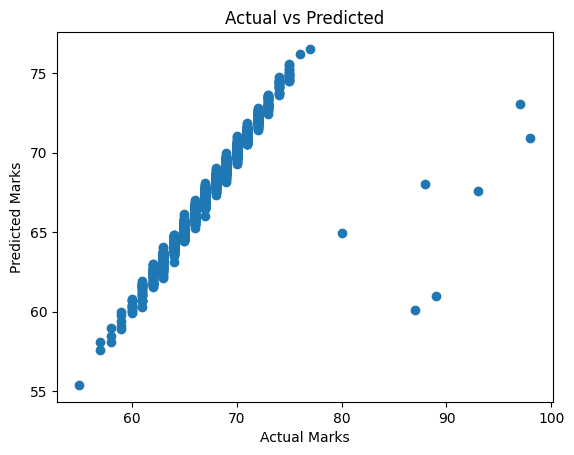

In [ ]:
import matplotlib.pyplot as plt

# create predictions
predictions = model.predict(X_test)

# print output
print("Predicted:", predictions)
print("Actual:", list(y_test))

# graph
plt.scatter(y_test, predictions)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()